In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils import ResultLoader, load_plot, load_plot_all_runs

# 设置绘图风格
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'figure.titlesize': 18
})

In [2]:
# 初始化加载器，指向 Ray 实验结果目录
loader = ResultLoader("../results_ray")

# 定义去中心化/点对点算法实验组
experiments = {
    # --- 基准对照 ---
    "Local": ("local", {}),

    # --- DFedUP 变体 ---
    "DFedUP": ("dfedup", {"mu": 0.1, "temp": 0.1}),
    "DFedUP1 (Orth)": ("dfedup1", {"mu": 0.1}),
    "DFedUP2 (MSE)": ("dfedup2", {"mu": 0.1}),

    # --- 其他去中心化基准算法 ---
    "L2C": ("l2c", {"val_ratio": 0.1, "lr_alpha": 0.1, "prune_round": 20, "prune_num": 0}),
    "DisPFL": ("dispfl", {"dense_ratio": 0.5, "anneal_factor": 1.0}),
    "PearFL": ("pearfl", {"lamda": 1.0}),
    "DFedAvgM": ("dfedavgm", {}),
    "DFedPGP": ("dfedpgp", {"local_v_epochs": 1, "lr_v": 0.01, "momentum_v": 0.0, "weight_decay_v": 0.0}),
    "ProxyFL": ("proxyfl", {"mu": 0.1})
}

# 快捷选择组
dfedup_family = ["DFedUP", "DFedUP1 (Orth)", "DFedUP2 (MSE)"]
baselines = ["Local", "L2C", "DisPFL", "PearFL", "DFedAvgM", "DFedPGP", "ProxyFL"]

# 在这里决定最终要对比的算法范围
selected_group = dfedup_family + baselines


In [3]:
# --- 实验参数配置 ---
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "num_clients": 10,
    "alpha": 0.1,
    "epochs": 10,
    "batch_size": 64,
    "lr": 0.01,
    "adj_type": "ring",
}

Figure saved to figures/test_accuracy_on_cifar10_dirichlet.png

Summary of ACC:
-----------------------------------------------------------------
Algorithm            |         Max Acc |     Last 10 Avg
-----------------------------------------------------------------
DFedUP               |         83.8127 |         83.1620
DFedUP1 (Orth)       |         83.3163 |         82.5905
DFedUP2 (MSE)        |         84.1217 |         83.7261
Local                |         83.4975 |         82.9064
L2C                  |         83.4782 |         83.2592
DisPFL               |         83.3862 |         82.8451
PearFL               |         84.5339 |         83.9471
DFedAvgM             |         77.5055 |         75.6400
DFedPGP              |         85.6607 |         85.3894
ProxyFL-Model        |         83.7510 |         83.4785
-----------------------------------------------------------------


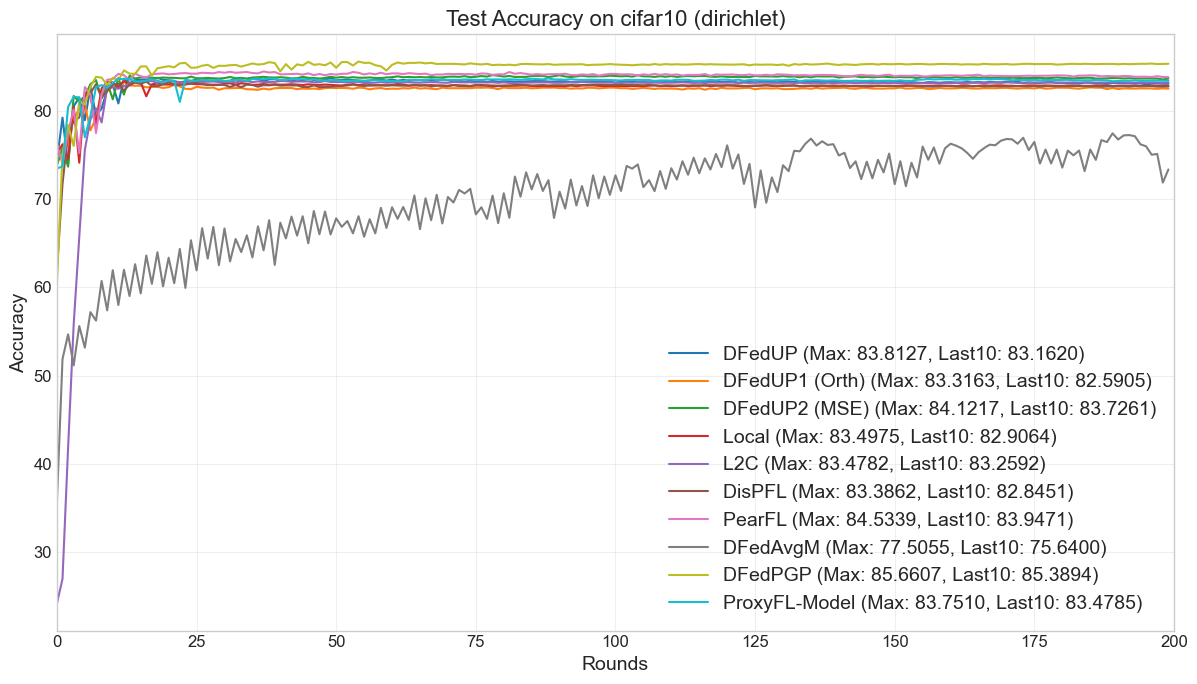

In [4]:
# 1. 绘制收敛曲线
load_plot(selected_group, experiments, common_args, loader, x_lim=200)

In [5]:
# 2. 统计多轮实验均值与方差
load_plot_all_runs(selected_group, experiments, common_args, loader, x_lim=200)


Summary of ALL RUNS (Mean ± Std):
---------------------------------------------------------------------------
Algorithm                 |              Max Acc |          Last 10 Avg
---------------------------------------------------------------------------
DFedUP                    |  83.8127 ± 0.0000  |  83.1620 ± 0.0000  (1 runs)
DFedUP1 (Orth)            |  83.3163 ± 0.0000  |  82.5905 ± 0.0000  (1 runs)
DFedUP2 (MSE)             |  84.1217 ± 0.0000  |  83.7261 ± 0.0000  (1 runs)
Local                     |  83.4975 ± 0.0000  |  82.9064 ± 0.0000  (1 runs)
L2C                       |  83.4782 ± 0.0000  |  83.2592 ± 0.0000  (1 runs)
DisPFL                    |  83.3862 ± 0.0000  |  82.8451 ± 0.0000  (1 runs)
PearFL                    |  84.5339 ± 0.0000  |  83.9471 ± 0.0000  (1 runs)
DFedAvgM                  |  77.5055 ± 0.0000  |  75.6400 ± 0.0000  (1 runs)
DFedPGP                   |  85.6607 ± 0.0000  |  85.3894 ± 0.0000  (1 runs)
ProxyFL-Model             |  83.7510 ± 0.0000  |